In [ ]:
# Frequency-only (DCT)
import os, cv2, numpy as np, random
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

Mounted at /content/drive
DCT shape: (10200, 128, 128, 1) labels: (10200,)
Epoch 1/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 78s 326ms/step - accuracy: 0.5331 - loss: 0.7486 - val_accuracy: 0.9123 - val_loss: 0.2480
Epoch 2/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 81s 323ms/step - accuracy: 0.8862 - loss: 0.2581 - val_accuracy: 0.9775 - val_loss: 0.0669
Epoch 3/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 81s 317ms/step - accuracy: 0.9678 - loss: 0.0903 - val_accuracy: 0.9745 - val_loss: 0.0654
Epoch 4/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 86s 337ms/step - accuracy: 0.9775 - loss: 0.0689 - val_accuracy: 0.9951 - val_loss: 0.0218
Epoch 5/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 75s 307ms/step - accuracy: 0.9884 - loss: 0.0366 - val_accuracy: 0.9863 - val_loss: 0.0376
Epoch 6/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 71s 305ms/step - accuracy: 0.9912 - loss: 0.0304 - val_accuracy: 0.9922 - val_loss: 0.0275
Epoch 7/10
234/234 ━━━━━━━━━━━━━━━━━━━━ 71s 305ms/step - accuracy: 0.9932 - loss: 0.0254 - val_accuracy: 0.9951 - val_loss: 0.0203
Epoch 8/

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
SEED=15
np.random.seed(SEED); random.seed(SEED); tf.random.set_seed(SEED)

In [ ]:
REAL_DIR = "/content/drive/My Drive/Research Project/Real_ffhq_5k"
FAKE_DIR = "/content/drive/My Drive/Research Project/StyleGAN2_256"
IMG_SIZE=(128,128)

In [ ]:
def load_dct(real_dir, fake_dir, img_size=(128,128), limit=None):
    X, y = [], []
    def proc(p):
        img = cv2.imread(p, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, img_size).astype(np.float32)/255.0
        freq = cv2.dct(img)
        freq_log = np.log(np.abs(freq)+1e-8)

        return freq_log[..., None]
    reals = sorted(os.listdir(real_dir))
    fakes = sorted(os.listdir(fake_dir))
    if limit: reals, fakes = reals[:limit], fakes[:limit]
    for fn in reals: X.append(proc(os.path.join(real_dir, fn))); y.append(0)
    for fn in fakes: X.append(proc(os.path.join(fake_dir, fn))); y.append(1)
    return np.array(X), np.array(y)

In [ ]:
X, y = load_dct(REAL_DIR, FAKE_DIR)
print("DCT shape:", X.shape, "labels:", y.shape)

In [ ]:
def build_branch(input_shape):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(16,(4,4),activation='relu')(inp)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32,(3,3),activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(32,(3,3),activation='relu')(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64,activation='relu')(x)
    out = layers.Dense(1,activation='sigmoid')(x)
    return models.Model(inp,out)

In [ ]:
model = build_branch((128,128,1))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
early_stop = EarlyStopping(monitor='val_loss', patience=9, restore_best_weights=True)
history = model.fit(Xtr, ytr, validation_data=(Xte,yte), epochs=20, batch_size=35, callbacks=[early_stop], verbose=1)

print("Test eval:", model.evaluate(Xte, yte, verbose=0))

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

from google.colab import drive
drive.mount('/content/drive')

REAL_TEST_DIR = "/content/drive/My Drive/Research Project/ffhq_2k"
FAKE_TEST_DIR = "/content/drive/My Drive/Research Project/Stylegan3_2k"

X_test,  y_test = load_dct(REAL_TEST_DIR, FAKE_TEST_DIR, img_size=IMG_SIZE, limit=None)

print("StyleGAN3 Test Shapes:", X_test.shape, y_test.shape)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=1)
print("StyleGAN3 Test Loss:", test_loss)
print("StyleGAN3 Test Accuracy:", test_acc)


y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32").flatten()

print("\nClassification Report (StyleGAN3 Test Set):")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
StyleGAN3 Test Shapes: (4079, 128, 128, 1) (4079,)
128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.9977 - loss: 0.0164
StyleGAN3 Test Loss: 0.011794565245509148
StyleGAN3 Test Accuracy: 0.9977935552597046
128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 66ms/step

Classification Report (StyleGAN3 Test Set):
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2079
        Fake       1.00      1.00      1.00      2000

    accuracy                           1.00      4079
   macro avg       1.00      1.00      1.00      4079
weighted avg       1.00      1.00      1.00      4079



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


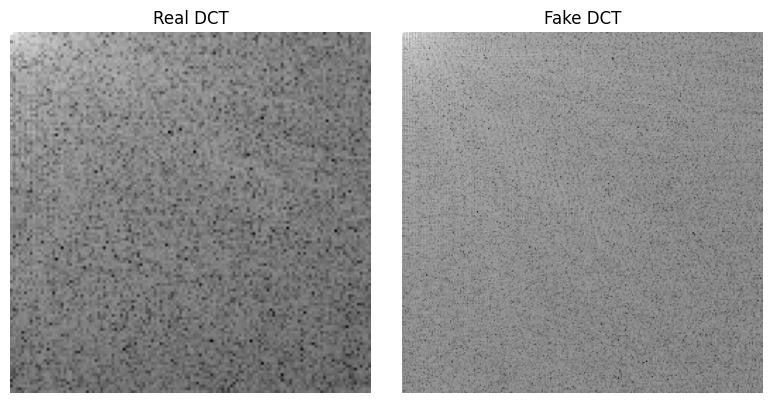

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

def dct_process(img_path):
    import cv2, numpy as np, os
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image: {img_path}")

    img = np.float32(img)

    dct_img = cv2.dct(img)

    freq_log = np.log(np.abs(dct_img) + 1e-8)

    mn, mx = freq_log.min(), freq_log.max()
    norm_img = (freq_log - mn) / (mx - mn + 1e-12)

    return norm_img

real_path = "/content/drive/My Drive/Research Project/Real_ffhq_5k/07467.png"

fake_path = "/content/drive/My Drive/Research Project/StyleGAN2_256/StyleGAN_2 (409).png"



real_dct = dct_process(real_path)
fake_dct = dct_process(fake_path)


plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(real_dct, cmap='gray')
plt.title("Real DCT")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(fake_dct, cmap='gray')
plt.title("Fake DCT")
plt.axis("off")

plt.tight_layout()
plt.show()